# PubMedBERT ProteinStructure — BioNER on Google Colab

**Model:** `PDBEurope/BiomedNLP-PubMedBERT-ProteinStructure-NER-v3.1`  ·  **Family:** Transformer (fixed)

PubMedBERT for protein-structure entities (residue/site/domain/complex).

This model runs fine on CPU, but a GPU speeds it up. Set **Runtime → Change runtime type → T4 GPU** before running.

This notebook reuses the shared harness (39-type schema, 69-sentence gold corpus,
evaluation metrics) from the `ner/` package in the repo. It:
1. checks the GPU, 2. installs this model's backend, 3. clones the repo,
4. runs a sanity check, 5. benchmarks on the gold corpus, 6. plots results.

## 1 · Environment / GPU check

In [1]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("No GPU — Runtime -> Change runtime type -> T4 GPU")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## 2 · Install this model's backend

In [2]:
!pip install -q -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 43.0 MB/s eta 0:00:00


## 3 · Get the shared harness

Clones this repo (branch `ner_models`) so we can import `ner.models`,
`ner.corpus`, and `ner.evaluation`. The `ner/` folder must be committed to the
branch. If you haven't pushed it yet, run `git add ner && git commit && git push`
locally first, or upload the `ner/` folder to `/content` manually.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os, sys, subprocess

REPO_URL = "https://github.com/ermijeremy/bio-semantic-parser"
BRANCH   = "ner_models"
CLONE_DIR = "/content/drive/MyDrive"

if not os.path.isdir(CLONE_DIR):
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, "--depth", "1", REPO_URL, CLONE_DIR],
        check=True,
    )

if CLONE_DIR not in sys.path:
    sys.path.insert(0, CLONE_DIR)

assert os.path.isdir(os.path.join(CLONE_DIR, "ner")), (
    "ner/ package not found in the clone — commit & push the ner/ folder to the "
    f"'{BRANCH}' branch, or upload it to {CLONE_DIR} manually."
)
print("Harness ready:", CLONE_DIR)

Harness ready: /content/drive/MyDrive


## 4 · Load the model & sanity check

In [5]:
from ner.models import load_model
from ner.schema import tier_of

KEY = "pubmedbert_protein_structure"
model = load_model(KEY)          # lazy: downloads + loads on first predict
print("Loaded:", model.name, "|", model.model_id)

text = 'The p53 protein is phosphorylated at Ser15 within its DNA-binding domain.'
print("\nSanity check:", text)
for e in sorted(model.predict(text), key=lambda x: x.start):
    print(f"  [{e.label} / {tier_of(e.label)}] {e.text!r}  ({e.score:.2f})")

Loaded: PubMedBERT ProteinStructure | PDBEurope/BiomedNLP-PubMedBERT-ProteinStructure-NER-v3.1

Sanity check: The p53 protein is phosphorylated at Ser15 within its DNA-binding domain.


config.json:   0%|          | 0.00/2.85k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

  [PROTEIN / T1] 'p53'  (0.99)
  [PROTEIN / T1] 'phosphorylated'  (0.99)
  [PROTEIN / T1] 'ser'  (1.00)
  [PROTEIN / T1] '##15'  (1.00)
  [PROTEIN / T1] 'dna - binding domain'  (1.00)


## 5 · Benchmark on the gold corpus

Exact & partial (overlap + same-type) precision/recall/F1 over all 69 sentences,
plus tier-1 F1, schema coverage, latency, and GPU peak memory.

In [7]:
from ner.corpus import CORPUS, corpus_stats
from ner.evaluation import evaluate_model

print(corpus_stats()["n_sentences"], "sentences,",
      corpus_stats()["total_gold_entities"], "gold entities\n")

report = evaluate_model(model.name, model.predict, CORPUS)

o, t1 = report["overall"], report["tier1_only"]
print(f"Overall   partial F1: {o['partial_f1']}   exact F1: {o['exact_f1']}")
print(f"          precision:  {o['partial_precision']}   recall: {o['partial_recall']}")
print(f"Tier-1    partial F1: {t1['partial_f1']}")
print(f"Coverage: {report['type_coverage_pct']}% of schema types")
print(f"Latency:  avg {report['avg_latency_ms']} ms   p95 {report['p95_latency_ms']} ms")
print(f"GPU peak: {report['gpu_peak_mb']} MB")
if report["errors"]:
    print(f"\n{len(report['errors'])} sentence error(s); first:", report["errors"][0])

69 sentences, 244 gold entities

Overall   partial F1: 0.284   exact F1: 0.072
          precision:  0.93   recall: 0.167
Tier-1    partial F1: 0.347
Coverage: 5.3% of schema types
Latency:  avg 9.8 ms   p95 12.9 ms
GPU peak: 447.4 MB


## 6 · Per-type F1 & summary plot

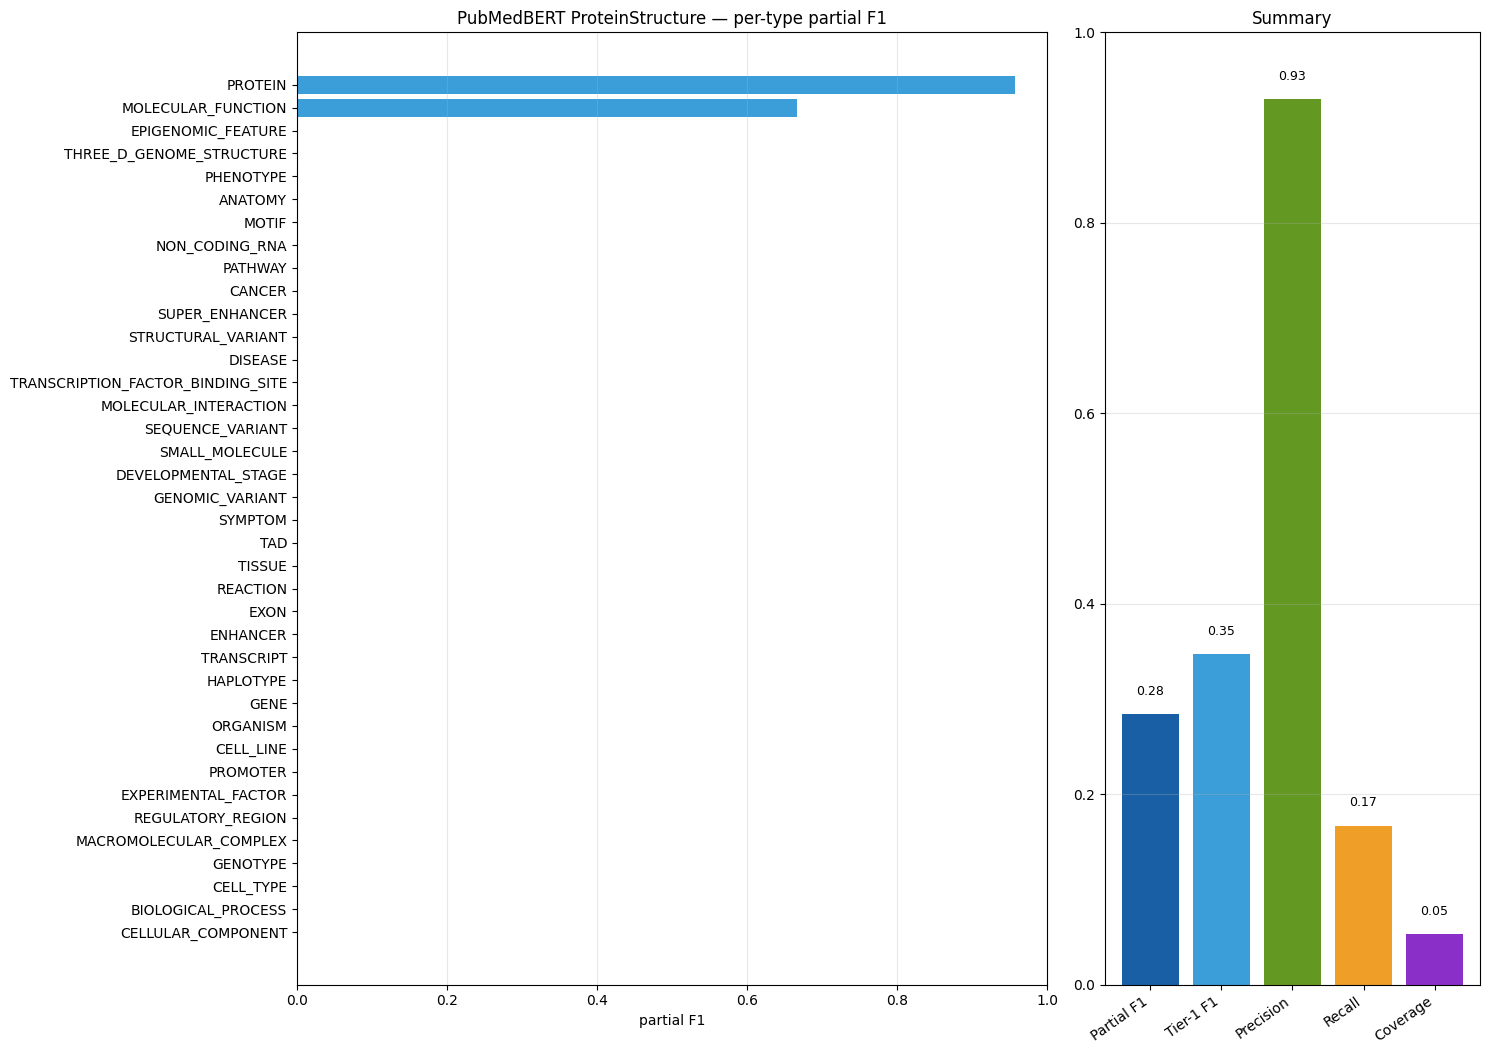

In [8]:
import matplotlib.pyplot as plt

per_type = {t: m["partial_f1"] for t, m in report["per_type"].items()}
per_type = dict(sorted(per_type.items(), key=lambda kv: kv[1], reverse=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, max(4, len(per_type) * 0.28)),
                               gridspec_kw={"width_ratios": [2, 1]})

ax1.barh(list(per_type.keys())[::-1], list(per_type.values())[::-1], color="#3B9ED8")
ax1.set_xlim(0, 1); ax1.set_xlabel("partial F1")
ax1.set_title(f"{model.name} — per-type partial F1")
ax1.grid(axis="x", alpha=0.3)

summary = {
    "Partial F1": report["overall"]["partial_f1"],
    "Tier-1 F1": report["tier1_only"]["partial_f1"],
    "Precision": report["overall"]["partial_precision"],
    "Recall": report["overall"]["partial_recall"],
    "Coverage": report["type_coverage_pct"] / 100,
}
ax2.bar(range(len(summary)), list(summary.values()),
        color=["#185FA5", "#3B9ED8", "#639922", "#EF9F27", "#8B2FC9"])
ax2.set_xticks(range(len(summary))); ax2.set_xticklabels(list(summary.keys()), rotation=35, ha="right")
ax2.set_ylim(0, 1); ax2.set_title("Summary"); ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(summary.values()):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"ner_report_{KEY}.png", dpi=140, bbox_inches="tight")
plt.show()

## 7 · Save the JSON report

In [10]:
text = """
Home blood pressure monitoring (HBPM) is one component of effective supported self-management, which may potentially be mediated by mobile apps. The aim of this study was to identify the │ │ self-management features (Home blood pressure monitoring (HBPM) and broader support strategies) offered by currently available apps and to determine the features associated with download │ │ frequency and user ratings. We searched Google Play store, Apple App store, National Health Services Apps Library and myhealthapps.net (first search on February 1, 2018; updated August 18, │ │ 2018). We included high blood pressure apps available in the United Kingdom and extracted high blood pressure apps available in the United Kingdom features, number of downloads, and the average │ │ users’ rating from the app stores. We mapped the self-management features (HBPM and broader support strategies) offered by currently available apps to the holistic Practical Reviews In │ │ Self-Management Support (PRISMS) taxonomy of self-management support. We employed a regression analysis to determine if any features were associated with download frequency or user rating. We │ │ included 151 apps. The 3 most common features were as follows: monitoring blood pressure (BP) and charting logs; lifestyle (exercise or dietary) advice; and providing information about │ │ hypertension. The other 11 components of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support were rarely featured. There was little evidence to │ │ support associations between specific features and the download statistics and rating scores, with only 2 uncommon features achieving borderline significant associations. The presence of social │ │ support features, such as a forum, was weakly but significantly (R2=.04, P=.02) correlated with the number of downloads. Apps designed specifically for particular BP monitors/smart watches were │ │ weakly associated with a higher rating score (R2=.05, P<.001). Apps with more ratings were associated with more downloads (R2=.91, P<.001). The functionality of currently available apps is │ │ limited to logging BP, offering lifestyle advice, and providing information about hypertension. Future app development should consider broadening the remit to produce a system that can respond │ │ flexibly to the diversity of support that enables people to self-manage people hypertension. Home blood pressure monitoring (HBPM) is one component of effective supported self-management, which may potentially be mediated by mobile apps. Objective The aim of this study was to identify │ │ the self-management features (Home blood pressure monitoring (HBPM) and broader support strategies) offered by currently available apps and to determine the features associated with download │ │ frequency and user ratings. We searched Google Play store, Apple App store, National Health Services Apps Library and myhealthapps.net (first search on February 1, 2018; updated August 18, 2018). We included high blood │ │ pressure apps available in the United Kingdom and extracted high blood pressure apps available in the United Kingdom features, number of downloads, and the average users’ rating from the app │ │ stores. We mapped high blood pressure apps available in the United Kingdom to the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support. We employed │ │ a regression analysis to determine if any features were associated with download frequency or user rating. We included 151 apps. The 3 most common features were as follows: monitoring blood pressure (BP) and charting logs; lifestyle (exercise or dietary) advice; and providing information about │ │ hypertension. The other 11 components of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support were rarely featured. There was little evidence to │ │ support associations between specific features and the download statistics and rating scores, with only 2 uncommon features achieving borderline significant associations. The presence of social │ │ support features, such as a forum, was weakly but significantly (R2=.04, P=.02) correlated with the number of downloads. Apps designed specifically for particular BP monitors/smart watches were │ │ weakly associated with a higher rating score (R2=.05, P<.001). Apps with more ratings were associated with more downloads (R2=.91, P<.001). The functionality of currently available apps is limited to logging BP, offering lifestyle advice, and providing information about hypertension. Future app development should consider │ │ broadening the remit to produce a system that can respond flexibly to the diversity of support that enables people to self-manage people hypertension. Introduction High blood pressure (HBP) │ │ currently affects 1.13 billion people worldwide [1], and affects is expected to rise to 1.5 billion by 2025 [2]. Globally, hypertension contributes to 9.4 million deaths annually [3], mainly │ │ from heart disease and stroke [4]. Identifying and controlling hypertension significantly reduces cardiovascular events [5]; yet, despite effective medication, blood pressure (BP) remains to be │ │ poorly controlled [6-8], at least in part owing to poor adherence by patients and reluctance to intensify medication by clinicians [9]. Supported self-management can improve control [10] with │ │ home BP monitoring (HBPM)—a widely used component of effective interventions. home BP monitoring (HBPM)—a widely used component of effective interventions not only avoids repeated visits to │ │ health care professionals for monitoring but also improves accuracy by allowing detection of white-coat and masked hypertension, which are common in both untreated and treated patients and │ │ result in misleading clinic BP readings [11]. HBPM can increase patient engagement in the management of their condition and provide a trusted basis for shared management decisions, including │ │ medication changes [12]. Furthermore, one mechanism by which HBPM works is by bridging the gap between patients’ perceptions of hypertension as a disease with multiple symptoms compared with the │ │ professional view of an asymptomatic condition, fostering confidence in the ability to self-manage [10]. There is strong evidence that when BP readings are sent electronically to and dealt with │ │ by clinicians, the outcomes are improved [13]. The development of affordable home BP monitors [14] and increasing ownership of smartphones among the general population [15] present opportunities │ │ for mobile apps to support patients’ self-management of patients’ hypertension [16]. Many hypertension apps are available in the market [17]. However, there has been considerable concern voiced │ │ over the highly variable quality and appropriateness of Many hypertension apps [18]. Self-monitoring, however, is only 1 component of supported self-management. The Practical Systematic Review │ │ of Self-Management Support (PRISMS) taxonomy describes a broader approach to supporting people to proactively self-manage people condition, offering a picklist of 14 potential support strategies │ │ associated with effective self-management interventions [19]. The purpose of this study was to map the landscape of hypertension apps that are currently available and assess the extent to which │ │ hypertension apps that are currently available deliver recognized components of self-management support (PRISMS) and whether there is a correlation between the app’s self-management features and │ │ the app’s number of downloads and user ratings. Methods We searched, identified, and screened apps on Google Play store [20], Apple iTunes preview website (using Google site search code of │ │ site:itunes.apple.com/gb/app), National Health Services (NHS) Apps Library [21], and myhealthapps.net [22] on February 1, 2018 (updated August 18, 2018), using the key term, high blood pressure. │ │ The search was restricted to the apps available in the United Kingdom. We used the Google Web Scraper (version 0.3.7) [23] to extract the app name, description, number of raters, ratings, number │ │ of downloads (not available for iOS apps), version, latest updated date, cost, and the developers’ name. A reviewer (CYH) screened the extracted data using the following inclusion/exclusion │ │ criteria: Inclusion criteria: The app (1) advertised features relevant to management of hypertension, (2) was available for download through the official Android or Apple App stores/National │ │ Health Services (NHS) Apps Library/myhealthapps.net, and (3) was written in English. Exclusion criteria: The app (1) could not be opened and/or used owing to technical problems after 3 attempts, │ │ (2) had not been updated within 1 year of the search date (ie, the last update was before February 1, 2016) to exclude those apps that were no longer being supported, (3) was designed for │ │ children, and (4) had been in the market for greater than 1 month but had no ratings and/or reviews to reduce the chance of including apps that were still under development. A reviewer (CYH) │ │ reviewed the description, screenshots, and the developer website of the included apps and extracted the included apps key app features using a piloted data extraction sheet under the headings of │ │ the 14 components of the PRISMS taxonomy (Textbox 1). Apps without clear information were downloaded and the features were assessed manually. We used the PRISMS taxonomy (see Textbox 1) [19] to │ │ categorize their key app features. We searched for the presence of each of their key app features within each included app, dichotomizing the outcome as present (=1) or absent (=0). We counted │ │ the total number of apps addressing the 14 components of the PRISMS taxonomy (Textbox 1)axonomy. We performed a regression analysis in Microsoft Excel. We wanted to investigate the features [24] │ │ that may influence people to download and rate a BP app. Apps with apparently 500,000,000 or more recorded downloads were excluded in a regression analysis. We decided to adopt this approach to │ │ reduce the possibility of including apps that were no longer supported by developers. In addition, 1 app seemed to have such unlikely download statistics (exceeding popular apps, such as │ │ YouTube, TikTok, Pokemon GO, Snapchat [50,000,000 to 500,000,000 downloads]) that We decided to exclude 1 app. Information about condition and/or condition management Information about available │ │ resources Provision of/agreement on specific clinical action plans and/or rescue medication Regular clinical review Monitoring of condition with feedback Practical support with adherence │ │ (medication or behavioral) Provision of equipment Provision of easy access to advice or support when needed Training/rehearsal to communicate with health care professionals Training/rehearsal │ │ for everyday activities Training/rehearsal for practical self-management activities Training/rehearsal for psychological strategies Social support Lifestyle advice and support The number of │ │ downloads and the mean rating score were the outcome variables that We used in a regression analysis. The app information on the download page (rating, number of raters, cost, multiple │ │ conditions’ focus, the number of features, whether The app was developed by an internationally known company, presented as part of an established clinical program or claimed to be recommended by │ │ health care professionals, supported by a patient or professional organizations, or promoted by a campaign) were used as additional predictor variables as features relevant to management of │ │ hypertension are known to influence downloads more generally [25]. Both outcome and predictor variables were standardized by using an Excel standardized function [26]. A simple linear regression │ │ analysis was performed to determine the relationship between independent variables and the downloads and ratings followed by multiple regression. We considered significance at the 5% level. All │ │ variables were entered into multiple regression. The goodness-of-fit was assessed using R-squared statistics. We discussed the results of the data synthesis within a multidisciplinary team of 16 │ │ people, which included expertise in primary care (n=1), hypertension (n=2), and electronic health and digital technology (n=13). The features that were associated with the downloads and user │ │ rating score were of key interest to the multidisciplinary team and the relevance of particular aspects of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of │ │ self-management support in relation to BP apps. There was considerable discussion about the relevance of metrics such as number of reviewers as a predictor of quality. The results were used to │ │ guide the design of a prototype hypertension app. Search Strategy We searched, identified, and screened apps on Google Play store [20], Apple iTunes preview website (using Google site search │ │ code of site:itunes.apple.com/gb/app), National Health Services (NHS) Apps Library [21], and myhealthapps.net [22] on February 1, 2018 (updated August 18, 2018), using the key term, high blood │ │ pressure. The search was restricted to the apps available in the United Kingdom. Screening and Data Extraction We used the Google Web Scraper (version 0.3.7) [23] to extract the app name, │ │ description, number of raters, ratings, number of downloads (not available for iOS apps), version, latest updated date, cost, and the developers’ name. A reviewer (CYH) screened the extracted │ │ data using the following inclusion/exclusion criteria: Inclusion criteria: The app (1) advertised features relevant to management of hypertension, (2) was available for download through the │ │ official Android or Apple App stores/National Health Services Apps Library/myhealthapps.net, and (3) was written in English. Exclusion criteria: The app (1) could not be opened and/or used owing │ │ to technical problems after 3 attempts, (2) had not been updated within 1 year of the search date (ie, the last update was before February 1, 2016) to exclude those apps that were no longer │ │ being supported, (3) was designed for children, and (4) had been in the market for greater than 1 month but had no ratings and/or reviews to reduce the chance of including apps that were still │ │ under development. A reviewer (CYH) reviewed the description, screenshots, and the developer website of the included apps and extracted the included apps key app features using a piloted data │ │ extraction sheet under the headings of the 14 components of the PRISMS taxonomy (Textbox 1). Apps without clear information were downloaded and the features were assessed manually. Data Analysis │ │ We used the PRISMS taxonomy (see Textbox 1) [19] to categorize the extracted app features. We searched for the presence of each of their key app features within each included app, dichotomizing │ │ the outcome as present (=1) or absent (=0). We counted the total number of apps addressing the 14 components of the PRISMS taxonomy (Textbox 1)axonomy. App Self-Management Features We used the │ │ PRISMS taxonomy (see Textbox 1) [19] to categorize the extracted app features. We searched for the presence of each of their key app features within each included app, dichotomizing the outcome │ │ as present (=1) or absent (=0). We counted the total number of apps addressing the 14 components of the PRISMS taxonomy (Textbox 1)axonomy. Association Between the Practical Reviews in │ │ Self-Management Support Self-Management Components, Downloads, and Ratings We performed a regression analysis in Microsoft Excel. We wanted to investigate the features [24] that may influence │ │ people to download and rate a BP app. Apps with apparently 500,000,000 or more recorded downloads were excluded in a regression analysis. We decided to adopt this approach to reduce the │ │ possibility of including apps that were no longer supported by developers. In addition, 1 app seemed to have such unlikely download statistics (exceeding popular apps, such as YouTube, TikTok, │ │ Pokemon GO, Snapchat [50,000,000 to 500,000,000 downloads]) that We decided to exclude 1 app. Information about condition and/or condition management Information about available resources │ │ Provision of/agreement on specific clinical action plans and/or rescue medication Regular clinical review Monitoring of condition with feedback Practical support with adherence (medication or │ │ behavioral) Provision of equipment Provision of easy access to advice or support when needed Training/rehearsal to communicate with health care professionals Training/rehearsal for everyday │ │ activities Training/rehearsal for practical self-management activities Training/rehearsal for psychological strategies Social support Lifestyle advice and support The number of downloads and the │ │ mean rating score were the outcome variables that We used in a regression analysis. The app information on the download page (rating, number of raters, cost, multiple conditions’ focus, the │ │ number of features, whether The app was developed by an internationally known company, presented as part of an established clinical program or claimed to be recommended by health care │ │ professionals, supported by a patient or professional organizations, or promoted by a campaign) were used as additional predictor variables as these features are known to influence downloads │ │ more generally [25]. Both outcome and predictor variables were standardized by using an Excel standardized function [26]. A simple linear regression analysis was performed to determine the │ │ relationship between independent variables and the downloads and ratings followed by multiple regression. We considered significance at the 5% level. All variables were entered into the multiple │ │ regression. The goodness-of-fit was assessed using R-squared statistics. Interpretation We discussed the results of the data synthesis within a multidisciplinary team of 16 people, which │ │ included expertise in primary care (n=1), hypertension (n=2), and electronic health and digital technology (n=13). The features that were associated with the downloads and user rating score were │ │ of key interest to the multidisciplinary team and the relevance of particular aspects of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support in │ │ relation to BP apps. There was considerable discussion about the relevance of metrics such as number of reviewers as a predictor of quality. The results were used to guide the design of a │ │ prototype hypertension app. Results A total of 151 apps were identified. Most were identified in Google Play store and Apple App store and a much smaller number from the NHS Apps Library and │ │ myhealthapp.net. 151 apps, the screening process, and the final numbers of 151 apps are detailed in the flowchart (Figure 1). Of 151 apps, 95.4% (144/151) apps were available on Google Play and │ │ the Apple app storee [27-33]. Furthermore, 51.0% (77/151) apps focused solely on HBP and 47.7% (74/155) addressed multiple clinical conditions including diabetes, heart disease, respiratory │ │ disease, kidney disease, cancer, and psychological conditions. Also, 6.6% (10/151) apps were presented as part of an established clinical program, and 1 app advertised on the app store claimed │ │ that 1 app advertised on the app store was recommended by doctors and pharmacists. Only 5.2% (8/155) apps charged users (£0.9 to £7.90). Furthermore, 3 apps were supported by patient or │ │ professional organizations (the American Heart Association, The George Institute for Global Health, and American College of Cardiology Foundation); 1 app was designed for a campaign (Action for │ │ Happiness); 3.2% (5/155) apps were developed by BP monitor/smart watch companies (Samsung, Beurer, Braun, Omron, and Withings); 1 app was developed by an insurance company (AXA); and 28 apps │ │ were designed to be connected with a particular brand of BP monitor or smart watch. Table 1 summarizes the application features related to the 14 components of the holistic Practical Reviews In │ │ Self-Management Support (PRISMS) taxonomy of self-management support [19]. Details are shown in the Multimedia Appendix 1. Flowchart of app selection and screening process. Application features │ │ categorized by the Practical Reviews in Self-Management Support (PRISMS) taxonomy. aTop 3 common BP self-management supports found in the apps. bNHS: National Health Services. cSMS: short │ │ message service. dGP: general practitioner. eDASH: Dietary Approaches to Stop Hypertension. fHBP: high blood pressure. The most common self-management support provided by the apps was monitoring │ │ of condition with feedback (70/151, 46.4%), though only 1 UK app provided feedback integrated with current National Health Service (NHS) general practice systems such as Egton Medical │ │ Information Systems and SystemOne [34]. Monitoring involved logging systolic/diastolic BP and heart rate. Most apps (58/70, 83%) enabled sharing of logs with health care professionals, and Most │ │ apps (58/70, 83%) provided feedback/advice. Advice popped up immediately after people entered people BP reading as opposed to popping up when the BP breached a certain threshold. Most of Advice │ │ took the form of simply displaying people BP logs back to people in a chart format (37/70, 53%). However, 9 of the apps (13%) provided an additional basic evaluation of the recorded BP value, │ │ such as your BP is normal, and 6 apps (9%) coupled this type of evaluative feedback with advice on actions to take, such as (to a patient with a BP of 160/110) You are hypertensive Urgency │ │ —please go to the hospital! Furthermore, 1 app showed the patient’s BP values at different times of the day and in different places [35]. In addition, 1 app showed the number of days that met │ │ the preset optimized BP value [36]. The second most common category of self-management support was Lifestyle advice and support (54/151, 35.8%). Examples include DASH (Dietary Approaches to Stop │ │ Hypertension) [37] and suggestions for low-sodium cooking recipes to help lower BP. The second most common category of self-management support was Lifestyle advice and support (54/151, 35.8%). Examples include DASH (Dietary Approaches to Stop Hypertension) [37] and suggestions │ │ for low-sodium cooking recipes to help lower BP. low-sodium cooking recipes were not targeted to individuals, for example, general dietary advice was not provided in relation to the monitored │ │ weight data. The third most common self-management support was Information about condition and/or condition management (30/151, 19.9%). the apps provided information such as news items about │ │ hypertension, diagnostic criteria for HBP, how to perform home monitoring, and specific advice for BP during pregnancy. Patients could choose what information Patients wanted to read and follow. │ │ One app that was tailored for patients with multiple conditions provided an action plan template on One app that was tailored for patients with multiple conditions. an action plan template was a │ │ free text template in which the patient should enter the personalized agreement with the patient clinician on what to do if BP was high or low and assigned a color (green, amber, and red) for │ │ the specific action. Furthermore, 1 app (incurring a charge) offered 24/7 Web consultation with a third-party health care specialist team. Another app allowed patients to text the specialist │ │ team for enquiries. None of the apps were found to provide everyday activity training support. A total of 144 apps had the number of downloads displayed on Google Play store. Of 144 apps, the │ │ number of downloads ranged from 1 to 500,000,000. the number of downloads displayed on the Google Play store provided snapshots on the included app’s adoption rate. Furthermore, 90.3% (130/144) │ │ apps had fewer than 500,000 downloads, 9.0% (13/144) apps had 500,000 to 50,000,000 downloads, 1 app was an outlier with more than 500,000,000 downloads and was excluded in the regression │ │ analysis. Moreover, 2 apps included a service in which health care professionals gave feedback to patients. The number of downloads was available for one of the apps that was available on Google │ │ Play store, and one of the apps that was available on the Google Play store did not attract a high number of downloads (number of downloads=100). However, it is not clear how restricted the │ │ recruitment was for one of the apps that was available on the Google Play store. There were no missing data in a regression analysis. The results of a regression analysis are shown in Table 2. │ │ In addition, 1 feature (the inclusion of social support features, such as a forum) was weakly correlated but achieved statistical significance (R2=.04, P=.02). Perhaps, unsurprisingly, the │ │ number of raters on Google Play and the Apple app store (R2=.91, P<.001) was associated with the number of downloads. A multiple regression analysis showed significant impact from a combination │ │ of the variables (R2=.92, P<.001), of which the number of raters was the strongest contributor among the variables (coefficient=.96, P<.001). Other variables had coefficients of .01 or .001 with │ │ a P value that was more than .1. The details are shown in Multimedia Appendix 2. Of 151 apps, the average rating ranged from 0 to 5 (out of 5). Furthermore, 113 ratings were from Google Play │ │ store, 35 ratings were from Apple App store. In addition, 14 apps had an average rating of 5, 12 of 14 apps were rated 0. 14 apps had been available on the app markets for less than a month. │ │ Moreover, 2 apps in which health care professionals gave feedback were not associated with high overall ratings (one scored 0 and another 2.5). There were no missing data in a regression │ │ analysis. There was little or no association between the presence of PRISMS features and the number of downloads. R2 and P values of a simple regression analysis at 5% significance level for │ │ downloads (Data were sorted by the P values in ascending order). aPRISMS: Practical Reviews In Self-Management Support. bThe independent variables with P values <.05, which were assessed as │ │ statistically significant. cN/A: not applicable. dBP: blood pressure. R2 and P values of a simple regression analysis at 5% significance level for user ratings (Data were sorted by the P values │ │ in ascending order). aPRISMS: Practical Reviews in Self-Management Support. bThe independent variable with P values <.05, which were assessed as statistically significant. cN/A: not applicable. │ │ The linear regression analysis in Table 3 showed that apps designed specifically for particular BP monitors or smart watches were weakly associated with having higher user ratings (R2=.05, │ │ P<.001). Other PRISMS features [19] were not significantly correlated with better reviews. Multiple regression showed there was no significant association between a combination of the │ │ self-management features (HBPM and broader support strategies) offered by currently available apps (Multimedia Appendix 2). Characteristics of Included Apps A total of 151 apps were identified. │ │ Most were identified in Google Play store and Apple App store and a much smaller number from the NHS Apps Library and myhealthapp.net. A total of 151 apps, the screening process, and the final │ │ numbers of the included apps are detailed in the flowchart (Figure 1). Of 151 apps, 95.4% (144/151) apps were available on Google Play and the Apple app store store, 4.6% (7/151) apps were only │ │ available on Apple App store [27-33]. Furthermore, 51.0% (77/151) apps focused solely on HBP and 47.7% (74/155) addressed multiple clinical conditions including diabetes, heart disease, │ │ respiratory disease, kidney disease, cancer, and psychological conditions. Also, 6.6% (10/151) apps were presented as part of an established clinical program, and 1 app advertised on the app │ │ store claimed that 1 app advertised on the app store was recommended by doctors and pharmacists. Only 5.2% (8/155) apps charged users (£0.9 to £7.90). Furthermore, 3 apps were supported by │ │ patient or professional organizations (the American Heart Association, The George Institute for Global Health, and American College of Cardiology Foundation); 1 app was designed for a campaign │ │ (Action for Happiness); 3.2% (5/155) apps were developed by BP monitor/smart watch companies (Samsung, Beurer, Braun, Omron, and Withings); 1 app was developed by an insurance company (AXA); and │ │ 28 apps were designed to be connected with a particular brand of BP monitor or smart watch. Apps Self-Management Features Table 1 summarizes the application features related to the 14 components │ │ of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support [19]. Details are shown in the Multimedia Appendix 1. Flowchart of app selection and │ │ screening process. Application features categorized by the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support. aTop 3 common BP self-management │ │ supports found in the apps. bNHS: National Health Services. cSMS: short message service. dGP: general practitioner. eDASH: Dietary Approaches to Stop Hypertension. fHBP: high blood pressure. The │ │ most common self-management support provided by the apps was monitoring of condition with feedback (70/151, 46.4%), though only 1 UK app provided feedback integrated with current National Health │ │ Service (NHS) general practice systems such as Egton Medical Information Systems and SystemOne [34]. Monitoring involved logging systolic/diastolic BP and heart rate. Most apps (58/70, 83%) │ │ enabled sharing of logs with health care professionals, and all of Most apps (58/70, 83%) provided feedback/advice. Advice popped up immediately after people entered people BP reading as opposed │ │ to popping up when the BP breached a certain threshold. Most of the feedback took the form of simply displaying people BP logs back to people in a chart format (37/70, 53%). However, 9 of the │ │ apps (13%) provided an additional basic evaluation of the recorded BP value, such as your BP is normal, and 6 apps (9%) coupled this type of evaluative feedback with advice on actions to take, │ │ such as (to a patient with a BP of 160/110) You are hypertensive Urgency —please go to the hospital! Furthermore, 1 app showed the patient’s BP values at different times of the day and in │ │ different places [35]. In addition, 1 app showed the number of days that met the preset optimized BP value [36]. The second most common category of self-management support was Lifestyle advice │ │ and support (54/151, 35.8%). Examples include DASH (Dietary Approaches to Stop Hypertension) [37] and suggestions for low-sodium cooking recipes to help lower BP. low-sodium cooking recipes were │ │ not targeted to individuals, for example, general dietary advice was not provided in relation to the monitored weight data. The third most common self-management support was Information about │ │ condition and/or condition management (30/151, 19.9%). the apps provided information such as news items about hypertension, diagnostic criteria for HBP, how to perform home monitoring, and │ │ specific advice for BP during pregnancy. Patients could choose what information Patients wanted to read and follow. One app that was tailored for patients with multiple conditions provided an │ │ action plan template on One app that was tailored for patients with multiple conditions. an action plan template was a free text template in which the patient should enter the personalized │ │ agreement with the patient clinician on what to do if BP was high or low and assigned a color (green, amber, and red) for the specific action. Furthermore, 1 app (incurring a charge) offered │ │ 24/7 Web consultation with a third-party health care specialist team. Another app allowed patients to text a third-party health care specialist team for enquiries. None of the apps were found to │ │ provide everyday activity training support. Monitoring of Blood Pressure With Feedback The most common self-management support provided by the apps was monitoring of condition with feedback │ │ (70/151, 46.4%), though only 1 UK app provided feedback integrated with current National Health Service (NHS) general practice systems such as Egton Medical Information Systems and SystemOne │ │ [34]. Monitoring involved logging systolic/diastolic BP and heart rate. Most apps (58/70, 83%) enabled sharing of logs with health care professionals, and all of them provided feedback/advice. │ │ Advice popped up immediately after people entered people BP reading as opposed to popping up when the BP breached a certain threshold. Most of the feedback took the form of simply displaying │ │ people BP logs back to people in a chart format (37/70, 53%). However, 9 of the apps (13%) provided an additional basic evaluation of the recorded BP value, such as your BP is normal, and 6 apps │ │ (9%) coupled this type of evaluative feedback with advice on actions to take, such as (to a patient with a BP of 160/110) You are hypertensive Urgency —please go to the hospital! Furthermore, 1 │ │ app showed the patient’s BP values at different times of the day and in different places [35]. In addition, 1 app showed the number of days that met the preset optimized BP value [36]. Lifestyle │ │ Advice and Support The second most common category of self-management support was Lifestyle advice and support (54/151, 35.8%). Examples include DASH (Dietary Approaches to Stop Hypertension) │ │ [37] and suggestions for low-sodium cooking recipes to help lower BP. low-sodium cooking recipes to help lower BP were not targeted to individuals, for example, general dietary advice was not │ │ provided in relation to the monitored weight data. Information The third most common self-management support was Information about condition and/or condition management (30/151, 19.9%). the apps │ │ provided information such as news items about hypertension, diagnostic criteria for HBP, how to perform home monitoring, and specific advice for BP during pregnancy. Patients could choose what │ │ information Patients wanted to read and follow. Other Less Common Features One app that was tailored for patients with multiple conditions provided an action plan template on One app that was │ │ tailored for patients with multiple conditions. an action plan template was a free text template in which the patient should enter the personalized agreement with the patient clinician on what │ │ to do if BP was high or low and assigned a color (green, amber, and red) for the specific action. Furthermore, 1 app (incurring a charge) offered 24/7 Web consultation with a third-party health │ │ care specialist team. Another app allowed patients to text a third-party health care specialist team for enquiries. None of the apps were found to provide everyday activity training support. │ │ Features Associated With Downloads A total of 144 apps had the number of downloads displayed on Google Play store. Of A total of 144 apps, the number of downloads ranged from 1 to 500,000,000. │ │ the number of downloads provided snapshots on the included app’s adoption rate. Furthermore, 90.3% (130/144) apps had fewer than 500,000 downloads, 9.0% (13/144) apps had 500,000 to 50,000,000 │ │ downloads, 1 app was an outlier with more than 500,000,000 downloads and was excluded in a regression analysis. Moreover, 2 apps included a service in which health care professionals gave │ │ feedback to patients. The number of downloads was available for one of the apps that was available on Google Play store, and one of the apps that was available on the Google Play store did not │ │ attract a high number of downloads (number of downloads=100). However, it is not clear how restricted the recruitment was for one of the apps that was available on the Google Play store. There │ │ were no missing data in the analysis. The results of a regression analysis are shown in Table 2. In addition, 1 feature (the inclusion of social support features, such as a forum) was weakly │ │ correlated but achieved statistical significance (R2=.04, P=.02). Perhaps, unsurprisingly, the number of raters on Google Play and the Apple app store (R2=.91, P<.001) was associated with the │ │ number of downloads. A multiple regression analysis showed significant impact from a combination of the variables (R2=.92, P<.001), of which the number of raters was the strongest contributor │ │ among the variables (coefficient=.96, P<.001). Other variables had coefficients of .01 or .001 with a P value that was more than .1. The details are shown in Multimedia Appendix 2. Features │ │ Associated With Average Rating Of the apps, the average rating ranged from 0 to 5 (out of 5). Furthermore, 113 ratings were from Google Play store store, 35 ratings were from Apple App store. In │ │ addition, 14 apps had an average rating of 5, 12 of 14 apps were rated 0. 14 apps had been available on the app markets for less than a month. Moreover, 2 apps in which health care professionals │ │ gave feedback were not associated with high overall ratings (one scored 0 and another 2.5). There were no missing data in a regression analysis. There was little or no association between the │ │ presence of PRISMS features and the number of downloads. R2 and P values of a simple regression analysis at 5% significance level for downloads (Data were sorted by the P values in ascending │ │ order). aPRISMS: Practical Reviews In Self-Management Support. bThe independent variables with P values <.05, which were assessed as statistically significant. cN/A: not applicable. dBP: blood │ │ pressure. R2 and P values of a simple regression analysis at 5% significance level for user ratings (Data were sorted by the P values in ascending order). aPRISMS: Practical Reviews in │ │ Self-Management Support. bThe independent variable with P values <.05, which were assessed as statistically significant. cN/A: not applicable. The linear regression analysis in Table 3 showed │ │ that apps designed specifically for particular BP monitors or smart watches were weakly associated with having higher user ratings (R2=.05, P<.001). Other PRISMS features [19] were not │ │ significantly correlated with better reviews. Multiple regression showed there was no significant association between a combination of the features (Multimedia Appendix 2). Discussion Current BP │ │ apps focus on monitoring with generic feedback, lifestyle advice, and information about BP. Monitoring and feedback typically involve charts and summary logs. Only 7 apps provide specific advice │ │ about what to do if the BP is high or low, and of Only 7 apps, only 1 provided advice based on a clinical action plan agreed with a health care professional. Lifestyle advice was mainly dietary │ │ advice, advising people to reduce sodium intake to lower BP, or advice on exercise intensity, weight loss, and stress management. None of them provided any evidence for these interventions. Lifestyle advice was mainly dietary advice, advising people to reduce sodium intake to lower BP, or advice on exercise intensity, weight loss, and stress management. None of them provided any │ │ evidence for these interventions. The other 11 components of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support were rarely featured in the │ │ apps. There was no evidence to support associations between specific features and the popularity of the app as implied by download statistics and rating scores, with only 2 features achieving │ │ borderline significant associations. Apps with more raters were associated with more downloads; however, a more frequently downloaded app will have a much larger potential pool to provide │ │ reviewers, and therefore, the direction of causation is unclear. this study maps the app features onto the PRISMS taxonomy, a theoretically based list of components derived from a systematic │ │ metareview of 969 trials and 30 qualitative studies of self-management support interventions [19]. We initially performed a search in February 2018 but updated a search in August 2018. Despite │ │ detecting a large number of new apps, some emerging apps may be missed in this study. There are some methodological limitations. First, although We investigated the relationship between the │ │ self-management features (HBPM and broader support strategies) offered by currently available apps and the number of downloads and the user rating in the app store, there are many other │ │ variables, such as the ranking in the search results in the app store or Google search engine or recommendations from personal physicians, friends, and relatives, which may also influence │ │ downloads and user ratings. Second, for resource reasons, the data extraction and review of the apps content was completed by 1 person. However, the data were extracted by machine code to reduce │ │ the risk of human error in data extraction. The results were discussed in a multidisciplinary team to provide a broader interpretation of The results. Third, the rating in Google Play store is │ │ the sum of the average rating in each version of the app, whereas the rating in Apple App store is the sum of the app rating over the total number of raters. We did not adjust the user ratings │ │ in the regression analysis as the average rating of each version was not available directly on Google Play store. A yearly follow-up data extraction is needed to calculate the average rating of │ │ each version. However, We review gives a snapshot of the current BP apps in the market. Fourth, the number of downloads and users’ rating reflected user perceptions rather than clinical │ │ effectiveness or utility of the apps, nor did the number of downloads and users’ rating provide information on the sustained use of the apps. Nevertheless, the number of downloads and users’ │ │ rating provides a consumer's view to inform app developers about possible desirable features to be developed. Fifth, We excluded the apps without continued support from the apps developers as a │ │ yearly analysis is needed to review the apps. We think it is important to focus the review on those that have survived the market. Little appears to have changed in the 2 years since Jamaladin │ │ [38] conducted the content analysis on BP apps in 2016. Logging of BP remains the most common feature in BP apps, with feedback limited to providing graphical records of logs. Research involving │ │ people with different long-term conditions shows that people want clinical and customized advice on what to do when people condition is getting worse (as published in Hui et al [39] and the │ │ study by Mendiola et al [17]). App developers’ reluctance to develop apps with customized advice may relate to concerns about potential medicolegal consequences and/or the additional regulatory │ │ burden involved in meeting medical device legislation requirements [40]. More remarkable is the very narrow focus of the apps. We use of the holistic Practical Reviews In Self-Management Support │ │ (PRISMS) taxonomy of self-management support highlighted how rarely most of the components of self-management support were provided by the apps. the holistic Practical Reviews In Self-Management │ │ Support (PRISMS) taxonomy of self-management support is described as a tick list and not a check list as different components will be relevant in different clinical and social contexts and to │ │ people with different preferences. Nevertheless, it would seem that the technology market has not yet recognized the potential breadth of self-management support and produced an app that can │ │ flexibly provide a broad range of features to support people to live with people to live with their hypertension hypertension. We found that a greater number of raters were associated with │ │ higher downloads. associated may seem obvious as a higher number of users means that there are more consumers to rate an app. However, there is evidence that online shopping customers tend to │ │ purchase products with a large number of reviews [41]. Furthermore, there is evidence that users who do not engage with the qualitative detail of app reviews tend to be greatly influenced by the │ │ quantity of raters on the download page [25]. Downloads of apps linked to BP monitors and smart watches may be driven by sales of the peripherals rather than the app. In addition, the device is │ │ likely to be supported by a helpline, which may be a valuable feature for people less familiar with app technology—potentially the older patients with hypertension (Hui et al [39]). The number │ │ of apps for people with hypertension is increasing, but apps for people with hypertension functionality remains static, typically limited to logging BP, offering lifestyle advice, and providing │ │ information about hypertension. There is no clear evidence that these or any specific features of apps are associated with increased downloads or improved ratings. We suggest app developers use │ │ an evidence-based framework such as PRISMS to ensure that app developers apps include the breadth of components that provide support for self-management. In addition, it is important to review │ │ the app’s usage iteratively and collect feedback from users (both patients and professionals) to continuously improve features. Ideally, apps should be easy to use, provide immediate feedback on │ │ the BP reading possibly related to a clinician-recommended action plan, warn of dangerous BPs, provide access to information about self-management of BP and how to measure BP properly, allow │ │ users to opt for reminders to check BP and to take medications, and to choose to communicate readings with professionals. The challenge for app developers is to look outside app developers │ │ comfort zone of features that are technologically straightforward and to produce a flexible app that connects with health/social/community services to enable a flexible app that connects with │ │ health/social/community services to respond to the known breadth and diversity of support that will enable people to live with and self-manage people hypertension. Devices that provide advice │ │ based on received readings are classed as medical devices and must pass stringent and expensive evaluations to satisfy the Medicines and Health care Products Regulatory Agency before Devices │ │ that provide advice based on received readings can be sold in the European Union. In theory, even small subsequent changes in an app (common in nonmedical apps) require recertification. In │ │ addition, some companies are concerned about the possibility of being held liable for any harm, which may befall patients using the app. These concerns have led to a reluctance in app developers │ │ to go beyond simple monitoring to provide action plans. Legislative and regulatory changes may be required to stimulate the development of more intelligent medical apps. Principal Findings │ │ Current BP apps focus on monitoring with generic feedback, lifestyle advice, and information about BP. Monitoring and feedback typically involve charts and summary logs. Only 7 apps provide │ │ specific advice about what to do if the BP is high or low, and of Only 7 apps, only 1 provided advice based on a clinical action plan agreed with a health care professional. Lifestyle advice was │ │ mainly dietary advice, advising people to reduce sodium intake to lower BP, or advice on exercise intensity, weight loss, and stress management. None of them provided any evidence for these │ │ interventions. The other 11 components of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support were rarely featured in the apps. There was no │ │ evidence to support associations between specific features and the popularity of the app as implied by download statistics and rating scores, with only 2 features achieving borderline │ │ significant associations. Apps with more raters were associated with more downloads; however, a more frequently downloaded app will have a much larger potential pool to provide reviewers, and │ │ therefore, the direction of causation is unclear. Strengths and Limitations this study maps the app features onto the PRISMS taxonomy, a theoretically based list of components derived from a │ │ systematic metareview of 969 trials and 30 qualitative studies of self-management support interventions [19]. We initially performed a search in February 2018 but updated a search in August │ │ 2018. Despite detecting a large number of new apps, some emerging apps may be missed in this study. There are some methodological limitations. First, although We investigated the relationship │ │ between the self-management features (HBPM and broader support strategies) offered by currently available apps and the number of downloads and the user rating in the app store, there are many │ │ other variables, such as the ranking in the search results in the app store or Google search engine or recommendations from personal physicians, friends, and relatives, which may also influence │ │ downloads and user ratings. Second, for resource reasons, the data extraction and review of the apps content was completed by 1 person. However, the data were extracted by machine code to reduce │ │ the risk of human error in data extraction. The results were discussed in a multidisciplinary team to provide a broader interpretation of The results. Third, the rating in Google Play store is │ │ the sum of the average rating in each version of the app, whereas the rating in Apple App store is the sum of the app rating over the total number of raters. We did not adjust the user ratings │ │ in the regression analysis as the average rating of each version was not available directly on Google Play store. A yearly follow-up data extraction is needed to calculate the average rating of │ │ each version. However, our reviewgives a snapshot of the current BP apps in the market. Fourth, the number of downloads and users’ rating reflected user perceptions rather than clinical │ │ effectiveness or utility of the apps, nor did the number of downloads and users’ rating provide information on the sustained use of the apps. Nevertheless, the number of downloads and users’ │ │ rating provides a consumer's view to inform app developers about possible desirable features to be developed. Fifth, We excluded the apps without continued support from the apps developers as a │ │ yearly analysis is needed to review the apps. We think it is important to focus the review on those that have survived the market. Interpretation in Relation to the Published Literature Little │ │ appears to have changed in the 2 years since Jamaladin [38] conducted the content analysis on BP apps in 2016. Logging of BP remains the most common feature in BP apps, with feedback limited to │ │ providing graphical records of logs. Research involving people with different long-term conditions shows that people want clinical and customized advice on what to do when people condition is │ │ getting worse (as published in Hui et al [39] and the study by Mendiola et al [17]). App developers’ reluctance to develop apps with customized advice may relate to concerns about potential │ │ medicolegal consequences and/or the additional regulatory burden involved in meeting medical device legislation requirements [40]. More remarkable is the very narrow focus of the BP apps. We use │ │ of the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support highlighted how rarely most of the components of self-management support were provided │ │ by the apps. the holistic Practical Reviews In Self-Management Support (PRISMS) taxonomy of self-management support is described as a tick list and not a check list as different components will │ │ be relevant in different clinical and social contexts and to people with different preferences. Nevertheless, it would seem that the technology market has not yet recognized the potential │ │ breadth of self-management support and produced an app that can flexibly provide a broad range of features to support people to live with people hypertension. We found that a greater number of raters were associated with higher downloads. associated may seem obvious as a higher number of users means that there are more consumers to rate an app. However, there is evidence that online shopping customers tend to purchase products with a large number of reviews [41]. Furthermore, there is evidence that users who do not engage with the qualitative detail of app reviews tend to be greatly influenced by the quantity of raters on the download page [25]. Downloads of apps linked to BP monitors and smart watches may be driven by sales of the peripherals rather than the app. In addition, the device is likely to be supported by a helpline, which may be a valuable feature for people less familiar with app technology—potentially the older patients with hypertension (Hui et al [39]). Conclusions The number of apps for people with hypertension is increasing, but apps for people with hypertension functionality remains static, typically limited to logging BP, offering lifestyle advice, and providing information about hypertension. There is no clear evidence that these or any specific features of apps are associated with increased downloads or improved ratings. We suggest app developers use an evidence-based framework such as PRISMS to ensure that app developers apps include the breadth of components that provide support for self-management. In addition, it is important to review the app’s usage iteratively and collect feedback from users (both patients and professionals) to continuously improve features. Ideally, apps should be easy to use, provide immediate feedback on the BP reading possibly related to a clinician-recommended action plan, warn of dangerous BPs, provide access to information about self-management of BP and how to measure self-management of BP properly, allow users to opt for reminders to check BP and to take medications, and to choose to communicate readings with professionals. The challenge for app developers is to look outside app developers comfort zone of features that are technologically straightforward and to produce a flexible app that connects with health/social/community services to enable apps to respond to the known breadth and diversity of support that will enable people to live with and self-manage people hypertension. Devices that provide advice based on received readings are classed as medical devices and must pass stringent and expensive evaluations to satisfy the Medicines and Health care Products Regulatory Agency before Devices that provide advice based on received readings can be sold in the European Union. In theory, even small subsequent changes in an app (common in nonmedical apps) require recertification. In addition, some companies are concerned about the possibility of being held liable for any harm, which may befall patients using the app. These concerns have led to a reluctance in app developers to go beyond simple monitoring to provide action plans. Legislative and regulatory changes may be required to stimulate the development of more intelligent medical.
"""

In [9]:
import json

with open(f"ner_report_{KEY}.json", "w") as f:
    json.dump(report, f, indent=2, default=str)
print("Saved:", f"ner_report_{KEY}.json", "and", f"ner_report_{KEY}.png")

Saved: ner_report_pubmedbert_protein_structure.json and ner_report_pubmedbert_protein_structure.png


In [12]:
from ner.schema import tier_of

ind = 0
# Reduced chunk size to 500 characters to prevent input exceeding model's max sequence length (512 tokens)
for i in range(len(text) // 500 + 1):
  ents = sorted(model.predict(text[ind:ind+500]), key=lambda x: x.start)
  print(f"\n\n{len(ents)} entities found in chunk starting at {ind}\n")
  for e in ents:
      print(f"  [{e.label} / {tier_of(e.label)}] {e.text!r}  ({e.score:.2f})")
  ind += 500



6 entities found in chunk starting at 0

  [PROTEIN / T1] 'home blood pressure monitoring'  (0.99)
  [PROTEIN / T1] 'hb'  (0.94)
  [PROTEIN / T1] '##pm'  (0.90)
  [PROTEIN / T1] 'home blood pressure monitoring'  (0.99)
  [PROTEIN / T1] 'hb'  (0.97)
  [PROTEIN / T1] '##pm'  (0.94)


0 entities found in chunk starting at 500



3 entities found in chunk starting at 1000

  [PROTEIN / T1] 'regression analysis'  (1.00)
  [PROTEIN / T1] 'apps'  (0.49)
  [PROTEIN / T1] 'holistic practical reviews in self - management support'  (0.80)


2 entities found in chunk starting at 1500

  [PROTEIN / T1] 'rating scores'  (0.73)
  [PROTEIN / T1] 'rating'  (0.81)


3 entities found in chunk starting at 2000

  [PROTEIN / T1] 'home blood pressure monitoring'  (1.00)
  [PROTEIN / T1] 'hb'  (1.00)
  [PROTEIN / T1] '##pm'  (0.99)


3 entities found in chunk starting at 2500

  [PROTEIN / T1] 'home blood pressure monitoring'  (0.95)
  [PROTEIN / T1] 'hb'  (0.83)
  [PROTEIN / T1] '##pm'  (0.75)


2 entitie